In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
dataset_path = "/content/drive/MyDrive/Hospital_Data"

In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [14]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    dataset_path + "/train",
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    dataset_path + "/val",
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

test_data = test_datagen.flow_from_directory(
    dataset_path + "/test",
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

Found 5222 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [15]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.6))

model.add(Dense(1, activation='sigmoid'))

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [17]:
history = model.fit(
    train_data,
    epochs=12,
    validation_data=val_data
)

Epoch 1/12
164/164 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.7710 - loss: 0.5148 - val_accuracy: 0.6875 - val_loss: 0.6079
Epoch 2/12
164/164 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - accuracy: 0.8658 - loss: 0.2964 - val_accuracy: 0.6875 - val_loss: 0.7643
Epoch 3/12
164/164 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.8861 - loss: 0.2552 - val_accuracy: 0.8125 - val_loss: 0.5428
Epoch 4/12
164/164 ━━━━━━━━━━━━━━━━━━━━ 315s 2s/step - accuracy: 0.9008 - loss: 0.2347 - val_accuracy: 0.8125 - val_loss: 0.4559
Epoch 5/12
164/164 ━━━━━━━━━━━━━━━━━━━━ 314s 2s/step - accuracy: 0.9067 - loss: 0.2454 - val_accuracy: 0.8750 - val_loss: 0.4370
Epoch 6/12
164/164 ━━━━━━━━━━━━━━━━━━━━ 314s 2s/step - accuracy: 0.9125 - loss: 0.2249 - val_accuracy: 0.8750 - val_loss: 0.4457
Epoch 7/12
164/164 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - accuracy: 0.9083 - loss: 0.2266 - val_accuracy: 0.6875 - val_loss: 0.9523
Epoch 8/12
164/164 ━━━━━━━━━━━━━━━━━━━━ 318s 2s/step - accuracy: 0.9267 - loss: 0.1991 - val_accu

In [18]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 911ms/step - accuracy: 0.8958 - loss: 0.3214
Test Accuracy: 0.8958333134651184


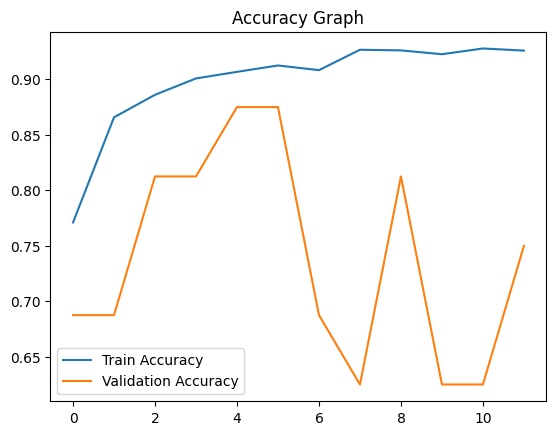

In [19]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()